In [19]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata
import os
from collections import Counter
from sklearn.decomposition import PCA


#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import anndata
from scipy import stats
import warnings
import logging


working_dic="/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/ECs/files/"
os.chdir(working_dic)


sc.settings.verbosity = 1
warnings.filterwarnings('ignore')
plt.rcParams['pdf.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
# ===== ADD THIS CRITICAL LINE =====
plt.rcParams['pdf.fonttype'] = 42  # Ensures editable text in PDFs
# ==================================


# --- add this near the top (after imports) ---
COND_ORDER = [
    "Control",
    "Standard protocol",
    "Extended protocol",
    "Prematurely terminated",
    "PCMV",
    "Rejection",
]

COND_PALETTE = {
    "Control": "#EFE48E",
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
    "Prematurely terminated": "#C9B8D9",
    "PCMV": "#F0C096",
    "Rejection": "#E09E9E",
}



In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#FF0000"])

In [21]:
global_adata = sc.read ('/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/NEW_cellchat/merging UMIs/CC_prepared_global_adata_raw_WITHOUT_lognorm.h5ad')

In [22]:
adata = global_adata.copy()

In [23]:
# Step 2: Preprocess - Normalize and Log Transform
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
# sc.pp.scale(vascular_ec_adata)

normalizing counts per cell
    finished (0:01:02)


In [24]:
# Subset AnnData for Vascular EC
vascular_ec_adata = adata[adata.obs["cell_type"] == "Vascular EC"].copy()

print(vascular_ec_adata)

print(vascular_ec_adata.obs["cell_type"].value_counts())


AnnData object with n_obs × n_vars = 8220 × 40653
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'n_counts_Papio_anubis', 'n_counts_Sus_scrofa', 'n_genes_Papio_anubis', 'n_genes_Sus_scrofa', 'Sample_ID', 'doublets_ncounts', 'leiden_02', 'cell_type', 'cell_type_V1', 'Treatment', 'Survival', 'Endpoint_status', 'Species', 'cell_states', 'leiden_annotated', 'pCMV_PCR_detected', 'pCMV_ELISA_detected', 'Survival_groups', 'Proliferating', 'pCMV_infected_cellstate', 'pCMV_score', 'n_genes_pCMV', 'pCMV_infection_threshold2', 'n_counts_pCMV', 'PCMV_infection', 'Conditions', 'Condition_subsets'
    uns: 'Sample_ID_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'
cell_type
Vascular EC    8220
Name: count, dtype: int64


In [6]:
# # Step 2: Preprocess - Normalize and Log Transform
# sc.pp.normalize_total(vascular_ec_adata)
# sc.pp.log1p(vascular_ec_adata)
# # sc.pp.scale(vascular_ec_adata)

normalizing counts per cell
    finished (0:00:02)


In [25]:
# Optional: standardize to uppercase for matching
vascular_ec_adata.var_names = vascular_ec_adata.var_names.str.upper()

# S phase genes
s_genes = [
    'PCNA', 'TYMS', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2', 'MCM6', 'CDCA7',
    'DTL', 'UHRF1', 'HELLS', 'RFC2', 'RPA2', 'NASP', 'RAD51AP1', 'GMNN',
    'WDR76', 'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'MSH2', 'ATAD2', 'RAD51',
    'RRM2', 'CDC45', 'CDC6', 'EXO1', 'TIPIN', 'DSCC1', 'BLM', 'CASP8AP2',
    'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8'
]

# G2M phase genes
g2m_genes = [
    'HMGB2', 'CDK1', 'NUSAP1', 'UBE2C', 'BIRC5', 'TPX2', 'TOP2A', 'NDC80',
    'CKS2', 'NUF2', 'MKI67', 'TMPO', 'CENPF', 'TACC3', 'SMC4', 'CCNB2',
    'CKAP2L', 'CKAP2', 'AURKB', 'BUB1', 'KIF11', 'ANP32E', 'TUBB4B', 'GTSE1',
    'KIF20B', 'HJURP', 'CDCA3', 'CDC20', 'TTK', 'CDC25C', 'KIF2C', 'RANGAP1',
    'NCAPD2', 'DLGAP5', 'CDCA2', 'CDCA8', 'ECT2', 'KIF23', 'HMMR', 'AURKA',
    'PSRC1', 'ANLN', 'LBR', 'CKAP5', 'CENPE', 'CTCF', 'NEK2', 'G2E3',
    'GAS2L3', 'CBX5', 'CENPA'
]


In [26]:
s_genes = [gene for gene in s_genes if gene in vascular_ec_adata.var_names]
g2m_genes = [gene for gene in g2m_genes if gene in vascular_ec_adata.var_names]

print(f"Found {len(s_genes)} S-phase genes and {len(g2m_genes)} G2M-phase genes in dataset.")


Found 39 S-phase genes and 51 G2M-phase genes in dataset.


In [27]:
sc.tl.score_genes_cell_cycle(vascular_ec_adata, s_genes=s_genes, g2m_genes=g2m_genes)


calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    350 total control genes are used. (0:00:00)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    427 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)


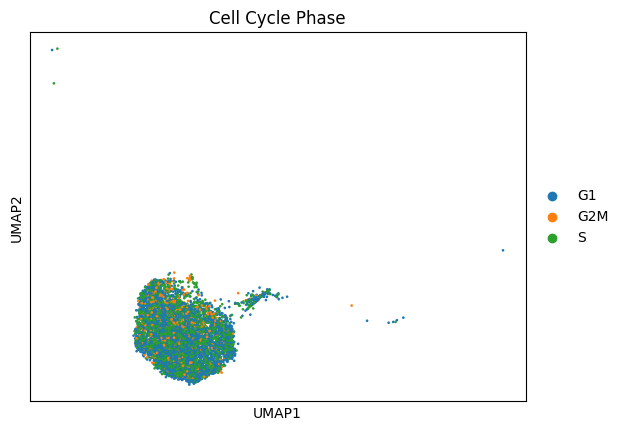

In [28]:
sc.pl.umap(vascular_ec_adata, color='phase', title='Cell Cycle Phase')


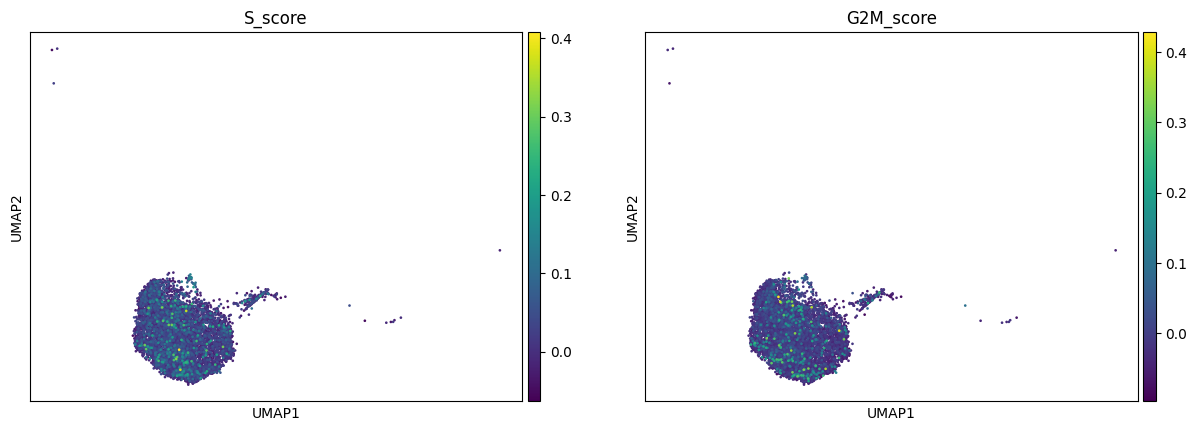

In [29]:
sc.pl.umap(vascular_ec_adata, color=['S_score', 'G2M_score'], cmap='viridis')


In [10]:
# Combine S and G2M genes (remove duplicates)
cell_cycle_genes = list(set(s_genes + g2m_genes))


computing PCA
    with n_comps=50
    finished (0:00:00)


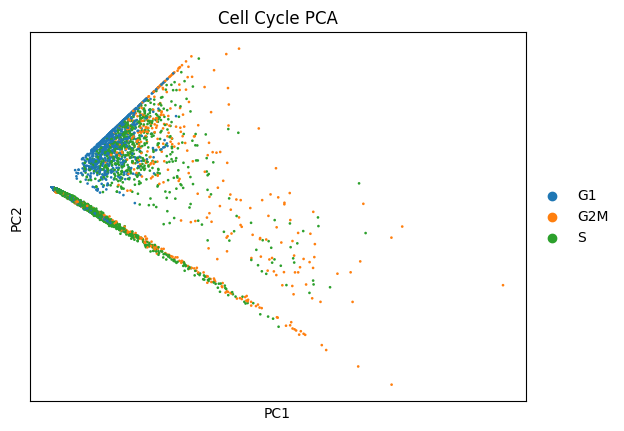

In [30]:
adata_cc_genes = vascular_ec_adata[:, cell_cycle_genes].copy()
sc.tl.pca(adata_cc_genes)
sc.pl.pca_scatter(adata_cc_genes, color='phase', title='Cell Cycle PCA')

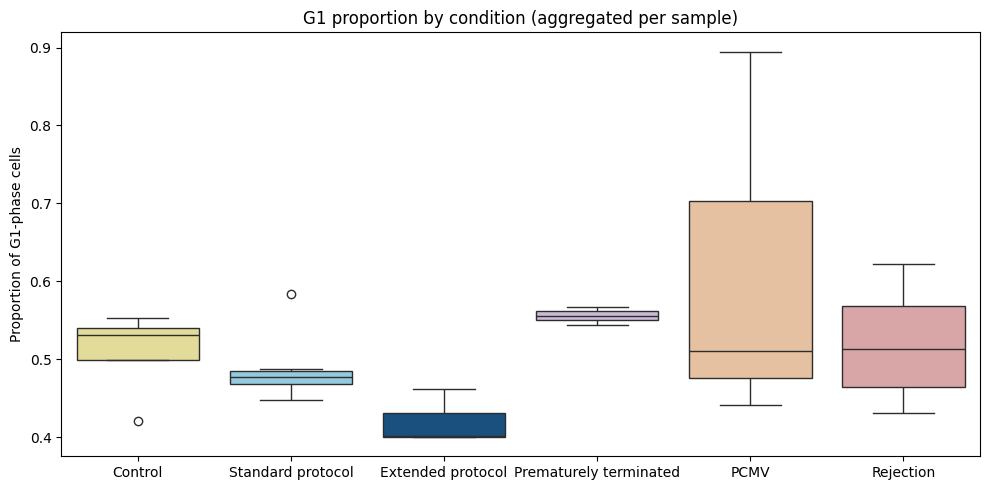

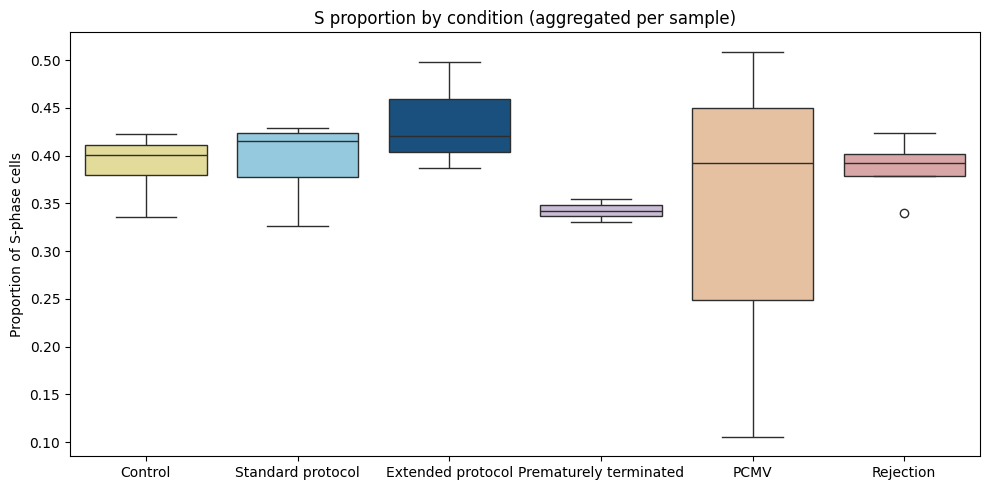

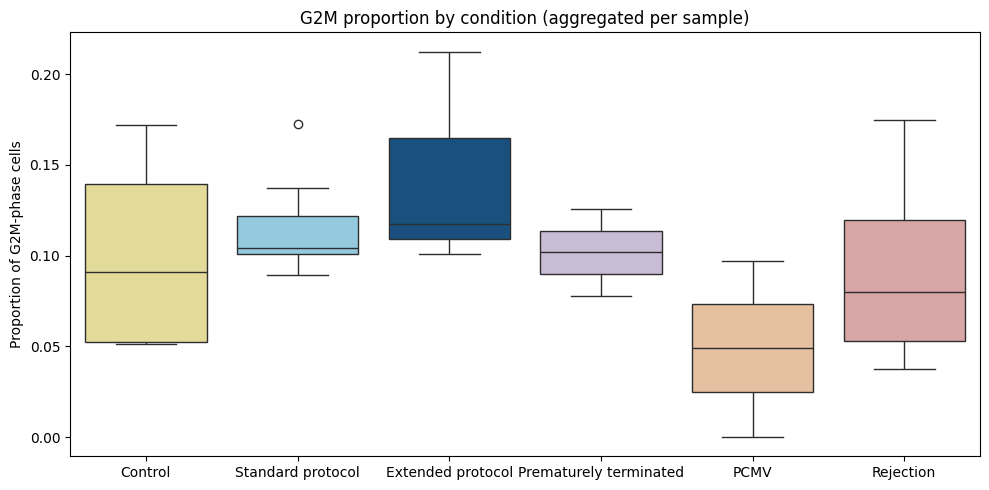

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- desired order & colors ---
COND_ORDER = [
    "Control",
    "Standard protocol",
    "Extended protocol",
    "Prematurely terminated",
    "PCMV",
    "Rejection",
]
COND_PALETTE = {
    "Control": "#EFE48E",
    "Standard protocol": "skyblue",
    "Extended protocol": "#08528f",
    "Prematurely terminated": "#C9B8D9",
    "PCMV": "#F0C096",
    "Rejection": "#E09E9E",
}

# Ensure phase indicator columns exist (booleans -> means become proportions)
vascular_ec_adata.obs['is_G1'] = (vascular_ec_adata.obs['phase'] == 'G1')
vascular_ec_adata.obs['is_S'] = (vascular_ec_adata.obs['phase'] == 'S')
vascular_ec_adata.obs['is_G2M'] = (vascular_ec_adata.obs['phase'] == 'G2M')

# Prepare dataframe using the correct condition column
df = vascular_ec_adata.obs[['Sample_ID', 'Condition_subsets', 'is_G1', 'is_S', 'is_G2M']].copy()

# Force the categorical order you want (even if some levels are sparse)
df['Condition_subsets'] = df['Condition_subsets'].cat.set_categories(COND_ORDER, ordered=True)

# Aggregate to per-sample proportions
grouped = (
    df.groupby(['Sample_ID', 'Condition_subsets'], observed=True)
      .mean(numeric_only=True)
      .reset_index()
)

def plot_phase(phase_col, title_phase):
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=grouped,
        x='Condition_subsets',
        y=phase_col,
        order=COND_ORDER,
        palette=COND_PALETTE,
        showfliers=True
    )
    plt.title(f'{title_phase} proportion by condition (aggregated per sample)')
    plt.ylabel(f'Proportion of {title_phase}-phase cells')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

# Draw the three panels
plot_phase('is_G1', 'G1')
plot_phase('is_S', 'S')
plot_phase('is_G2M', 'G2M')


In [13]:
# Get unique cell states
unique_cell_states = sorted(vascular_ec_adata.obs['cell_states'].unique())
print(unique_cell_states)


['Angiogenic_EC', 'Anti_inflammatory_EC', 'Arterial_EC', 'Cap_EC', 'Cap_EC_ISG', 'EC_pCMVpos_sus', 'Hypoxia_EC', 'Meso_EC', 'NFkB_EC', 'Prolif_EC']


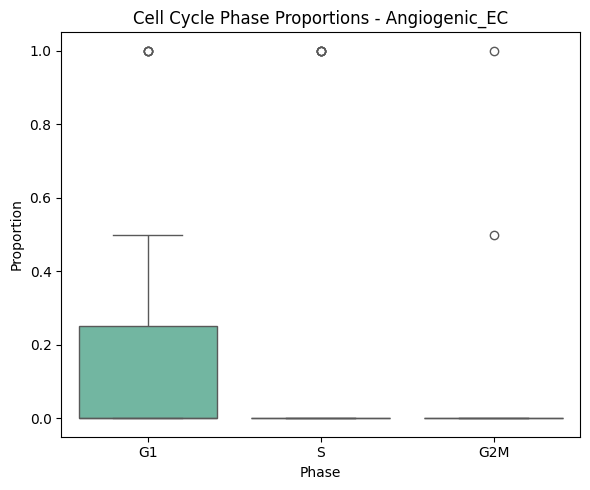

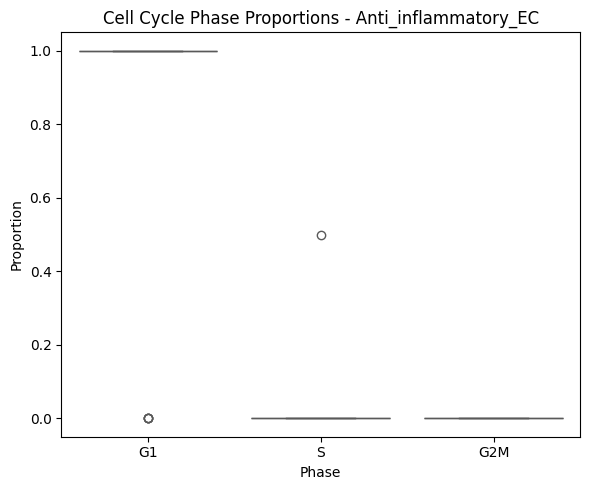

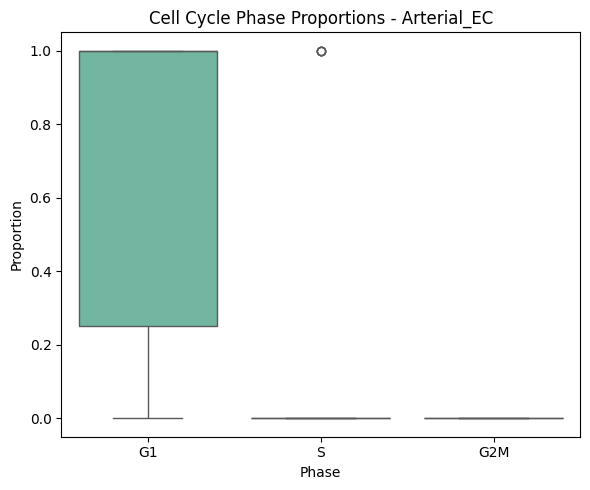

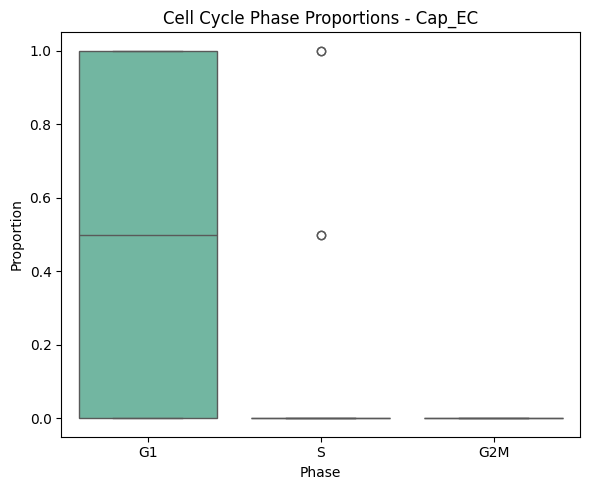

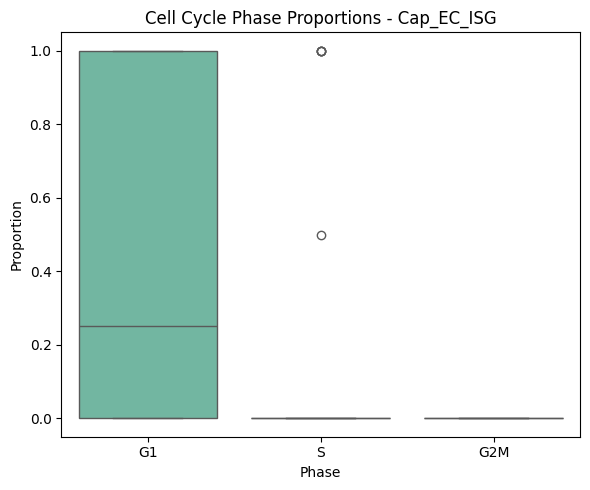

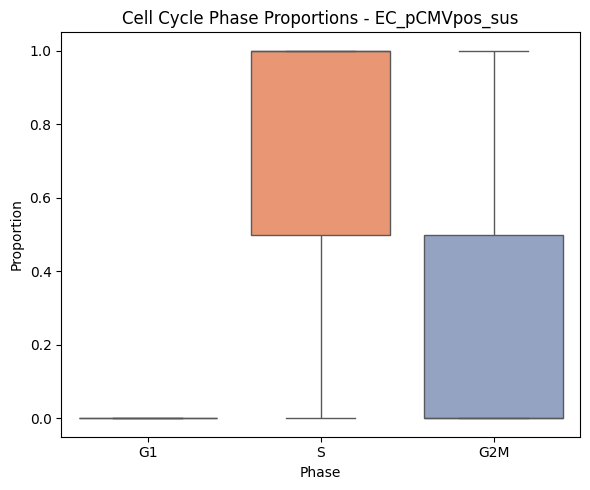

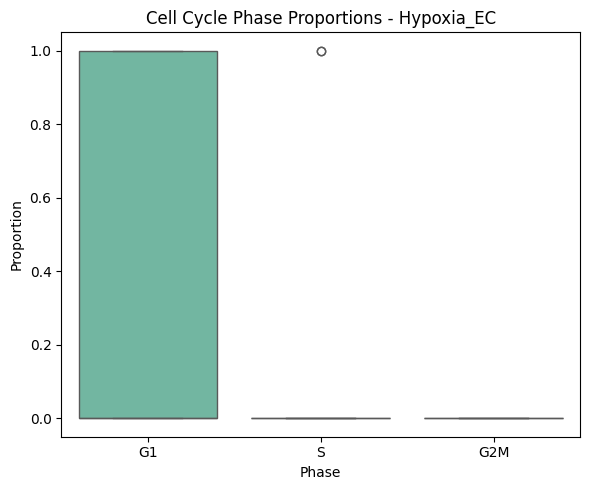

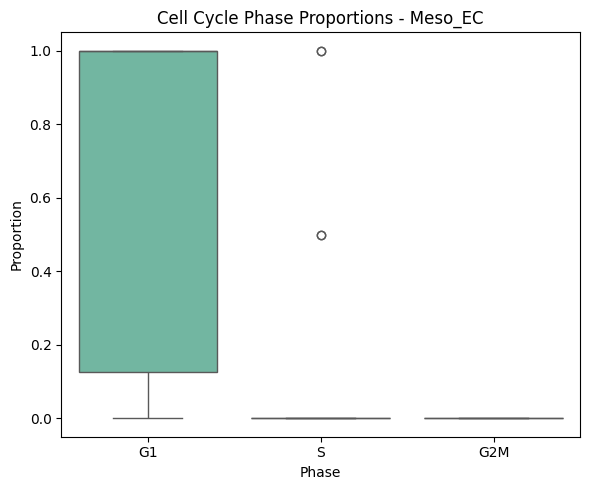

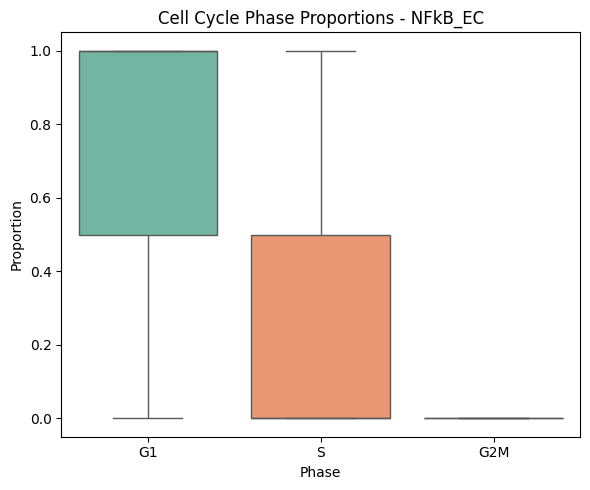

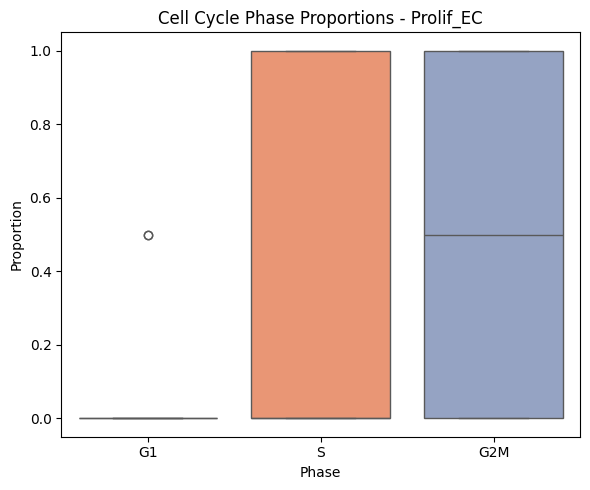

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define colors for phases
phase_colors = {'G1': '#66c2a5', 'S': '#fc8d62', 'G2M': '#8da0cb'}

# Ensure indicator columns exist
vascular_ec_adata.obs['is_G1'] = vascular_ec_adata.obs['phase'] == 'G1'
vascular_ec_adata.obs['is_S'] = vascular_ec_adata.obs['phase'] == 'S'
vascular_ec_adata.obs['is_G2M'] = vascular_ec_adata.obs['phase'] == 'G2M'

# Prepare DataFrame
df = vascular_ec_adata.obs[['Sample_ID', 'cell_states', 'is_G1', 'is_S', 'is_G2M']].copy()
grouped = df.groupby(['Sample_ID', 'cell_states']).median().reset_index()

# Loop over unique cell states
unique_states = sorted(grouped['cell_states'].unique())

for state in unique_states:
    state_df = grouped[grouped['cell_states'] == state]

    # Reshape data to long format for seaborn boxplot
    melted = state_df.melt(
        id_vars=['Sample_ID'], 
        value_vars=['is_G1', 'is_S', 'is_G2M'],
        var_name='Phase', 
        value_name='Proportion'
    )
    
    # Map simplified phase names for clarity
    melted['Phase'] = melted['Phase'].map({
        'is_G1': 'G1',
        'is_S': 'S',
        'is_G2M': 'G2M'
    })

    # Plot
    plt.figure(figsize=(6, 5))
    sns.boxplot(
        data=melted,
        x='Phase',
        y='Proportion',
        palette=phase_colors,
        showfliers=True
    )
    plt.title(f'Cell Cycle Phase Proportions - {state}')
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


In [34]:
import os
import matplotlib.pyplot as plt

# --- output folder ---
outdir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs"
os.makedirs(outdir, exist_ok=True)

# --- count & percent ---
phase_counts = (
    vascular_ec_adata.obs
    .groupby(['cell_states', 'phase'])
    .size()
    .reset_index(name='count')
)
phase_counts['percent'] = (
    phase_counts.groupby('cell_states')['count']
                .transform(lambda x: 100 * x / x.sum())
)

# --- phase order & colors ---
PHASE_ORDER = ['G1', 'S', 'G2M']
PHASE_COLORS = {
    'G1': "#66c2a5",   # teal/green
    'S':  "#fc8d62",   # orange
    'G2M': "#8da0cb"   # purple/blue
}

# --- make a pie for each cell state and save ---
for state in phase_counts['cell_states'].unique():
    sub = phase_counts[phase_counts['cell_states'] == state]
    sub = sub.set_index('phase').reindex(PHASE_ORDER).reset_index().dropna()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(
        sub['percent'],
        labels=sub['phase'],
        autopct='%1.1f%%',
        colors=[PHASE_COLORS[p] for p in sub['phase']]
    )
    ax.set_title(state)

    outpath = os.path.join(outdir, f"{state}_cellcycle_pie.pdf")
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)  # close to free memory

print(f"Saved {len(phase_counts['cell_states'].unique())} pie charts in {outdir}")


Saved 10 pie charts in /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import math

# 1) choose states
SELECTED_STATES = ["Prolif_EC", "EC_pCMVpos_sus"]

# 2) colors & order
PHASE_ORDER = ["G1", "S", "G2M"]
PHASE_COLORS = {"G1": "#66c2a5", "S": "#fc8d62", "G2M": "#8da0cb"}

# 3) data prep
phase_counts = (
    vascular_ec_adata.obs
    .groupby(["cell_states", "phase"])
    .size()
    .reset_index(name="count")
)
phase_counts = phase_counts[phase_counts["cell_states"].isin(SELECTED_STATES)].copy()
phase_counts["percent"] = (
    phase_counts.groupby("cell_states")["count"].transform(lambda x: 100 * x / x.sum())
)

def get_state_df(state):
    sub = phase_counts[phase_counts["cell_states"] == state][["phase", "percent"]]
    sub = sub.set_index("phase").reindex(PHASE_ORDER).fillna({"percent": 0}).reset_index()
    return sub

# 4) layout
n = len(SELECTED_STATES)
ncols = min(3, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 4.0 * nrows), squeeze=False)

def autopct_fmt(pct):
    return f"{pct:.1f}%" if pct >= 0.5 else ""

# 5) plot
for i, state in enumerate(SELECTED_STATES):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    sub = get_state_df(state)
    ax.pie(
        sub["percent"].to_numpy(),
        labels=sub["phase"],
        autopct=autopct_fmt,
        startangle=90,
        counterclock=False,
        colors=[PHASE_COLORS[p] for p in sub["phase"]],
        wedgeprops=dict(linewidth=0.8, edgecolor="white"),
    )
    ax.set_title(state, fontsize=12)
    ax.axis("equal")

# hide unused axes
for j in range(n, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")

# 6) save BEFORE show
outdir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs"
os.makedirs(outdir, exist_ok=True)
outpath = os.path.join(outdir, "SelectedStates_cellcycle_pies_panel.pdf")

fig.tight_layout()
fig.savefig(outpath, dpi=300, bbox_inches="tight")  # <-- save first
# plt.show()  # optionally show after saving
plt.close(fig)

print(f"Saved panel to: {outpath}")


Saved panel to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs/SelectedStates_cellcycle_pies_panel.pdf


In [18]:
import pandas as pd
import os

# --- Output directory setup ---
# Adjust this path as needed, I'm using your existing base directory structure
outdir = "/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs"
os.makedirs(outdir, exist_ok=True)
print(f"Saving scoring CSVs to: {outdir}")

# --- Preparation: Ensure phase indicator columns and scoring columns are ready ---

# Note: The is_G1, is_S, is_G2M columns are already created in your prior code,
# but it's good practice to ensure they exist for robustness.
vascular_ec_adata.obs['is_G1'] = (vascular_ec_adata.obs['phase'] == 'G1').astype(int)
vascular_ec_adata.obs['is_S'] = (vascular_ec_adata.obs['phase'] == 'S').astype(int)
vascular_ec_adata.obs['is_G2M'] = (vascular_ec_adata.obs['phase'] == 'G2M').astype(int)

# Columns to use for aggregation
score_cols = ['S_score', 'G2M_score', 'is_G1', 'is_S', 'is_G2M']

# --- AGGREGATION FUNCTION (reused for both new groups) ---
def aggregate_scores(df, group_keys):
    """Aggregates cell cycle scores (median) and phase proportions (mean)"""
    return (
        df.groupby(group_keys, observed=True)
        .agg(
            N_cells=('S_score', 'size'), # Add a count of cells for reference
            S_score_median=('S_score', 'median'),
            G2M_score_median=('G2M_score', 'median'),
            Proportion_G1=('is_G1', 'mean'),
            Proportion_S=('is_S', 'mean'),
            Proportion_G2M=('is_G2M', 'mean')
        )
        .reset_index()
    )
# ----------------------------------------------------------------------------------------------------------------------
# --- 1. Original Aggregation by Condition_subsets ---

# Select relevant columns
df_condition = vascular_ec_adata.obs[['Condition_subsets'] + score_cols].copy()

grouped_condition = aggregate_scores(df_condition, group_keys=['Condition_subsets'])
grouped_condition.rename(columns={'Condition_subsets': 'Condition'}, inplace=True)

# Save the aggregated data
condition_outfile = os.path.join(outdir, "vascular_ec_cellcycle_scores_per_condition.csv")
grouped_condition.to_csv(condition_outfile, index=False)
print(f"Successfully saved per-condition scoring data to: {condition_outfile}")

# ----------------------------------------------------------------------------------------------------------------------
## --- 3. NEW: Aggregate and Save by Condition_subsets and cell_states ---

# Select relevant columns, including 'cell_states'
df_condition_state = vascular_ec_adata.obs[['Condition_subsets', 'cell_states'] + score_cols].copy()

# Group by both Condition and cell_states
grouped_condition_state = aggregate_scores(
    df_condition_state,
    group_keys=['Condition_subsets', 'cell_states']
)
grouped_condition_state.rename(columns={'Condition_subsets': 'Condition'}, inplace=True)

# Save the aggregated data
condition_state_outfile = os.path.join(outdir, "vascular_ec_cellcycle_scores_per_condition_and_state.csv")
grouped_condition_state.to_csv(condition_state_outfile, index=False)
print(f"Successfully saved per-condition & cell-state scoring data to: {condition_state_outfile}")

# ----------------------------------------------------------------------------------------------------------------------
# --- 2. Original Aggregation by Sample_ID ---

# Select relevant columns
df_sample = vascular_ec_adata.obs[['Sample_ID', 'Condition_subsets'] + score_cols].copy()

grouped_sample = aggregate_scores(df_sample, group_keys=['Sample_ID', 'Condition_subsets'])

# Save the aggregated data
sample_outfile = os.path.join(outdir, "vascular_ec_cellcycle_scores_per_sample.csv")
grouped_sample.to_csv(sample_outfile, index=False)
print(f"Successfully saved per-sample scoring data to: {sample_outfile}")

# ----------------------------------------------------------------------------------------------------------------------
## --- 4. NEW: Aggregate and Save by Sample_ID and cell_states ---

# Select relevant columns, including 'cell_states'
df_sample_state = vascular_ec_adata.obs[['Sample_ID', 'Condition_subsets', 'cell_states'] + score_cols].copy()

# Group by Sample_ID, Condition_subsets, and cell_states
grouped_sample_state = aggregate_scores(
    df_sample_state,
    group_keys=['Sample_ID', 'Condition_subsets', 'cell_states']
)

# Save the aggregated data
sample_state_outfile = os.path.join(outdir, "vascular_ec_cellcycle_scores_per_sample_and_state.csv")
grouped_sample_state.to_csv(sample_state_outfile, index=False)
print(f"Successfully saved per-sample & cell-state scoring data to: {sample_state_outfile}")

print("\nAll four cell cycle scoring CSVs for Vascular ECs have been saved.")

Saving scoring CSVs to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs
Successfully saved per-condition scoring data to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs/vascular_ec_cellcycle_scores_per_condition.csv
Successfully saved per-condition & cell-state scoring data to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs/vascular_ec_cellcycle_scores_per_condition_and_state.csv
Successfully saved per-sample scoring data to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs/vascular_ec_cellcycle_scores_per_sample.csv
Successfully saved per-sample & cell-state scoring data to: /data2/core-med1/nhadizad/nastaran/Xenotransplant/global/cell cycle scoring/vascular_ECs/vascular_ec_cellcycle_scores_per_sample_and_state.csv

All four cell cycle scoring CSVs for Vascular ECs have been saved.
